# **Proyecto ABP 6: Aprendizaje de Máquina Supervisado - Predicción inteligente de Gasto en Clientes E-commerce**

**Autora:** Bernardita Ortega.

### **Situación inicial 📍**

#### **Unidad solicitante: Departamento de Analítica Comercial de una empresa de e-commerce.**

La empresa busca optimizar su estrategia de marketing personalizando ofertas según el perﬁl de cada usuario. Para lograr esto, necesita construir un modelo de aprendizaje de máquina capaz de predecir el monto promedio de compra de un cliente en función de características como edad, comportamiento en el sitio y otras variables demográﬁcas. Los analistas internos tienen datos históricos pero no cuentan con un modelo predictivo robusto. Se requiere un equipo que pueda diseñar una solución integral aplicando técnicas de aprendizaje supervisado, evaluando el ajuste, rendimiento y mejorando progresivamente su desempeño. .

### **Nuestro objetivo 📋**

Diseñar e implementar un modelo predictivo de regresión que permita estimar el monto de compra esperado por un cliente. El objetivo es utilizar los datos históricos disponibles, aplicar preprocesamiento y técnicas de validación cruzada, seleccionar y entrenar algoritmos adecuados, evaluarlos con métricas especíﬁcas y optimizar su rendimiento hasta llegar a un modelo ﬁnal funcional y conﬁable..

## **Lección 1 - *Fundamentos del Aprendizaje de Máquina***

📌 **Objetivo:** Comprender los fundamentos del aprendizaje supervisado.

📍 **Tareas desarrolladas:**

1. **Diferenciar problemas de clasificación y regresión.**

    La regresión busca predecir un valor numérico continuo, mientras que la clasificación intenta predecir o asignar una etiqueta, clases o categoría específica a partir de las características de los datos.

2. **Identificar las etapas del pipeline de un proyecto ML.**

El flujo de trabajo de manera general de un proyecto de Machine Learning, seria:

    - Definición del Problema
    - Recolección de Datos
    - Exploración de Datos (EDA)
    - Preprocesamiento de los Datos
    - División de los Datos (train/test split)
    - Entrenamiento del Modelo
    - Evaluación del Modelo
    - Ajuste y Validación del Modelo
    - Implementación
    - Monitoreo y Mantenimiento

3. **Definir el problema como regresión supervisada.**

    El proyecto es un problema de regresión supervisada, ya que busca predecir un valor numérico continuo: el monto promedio de compra de un cliente. El modelo debe aprender la relación entre ciertas características y el monto de compra. Este problema implica predecir valores numéricos, no categorías. El modelo entrenado utilizará estos datos para hacer predicciones sobre el gasto de futuros clientes.

## **Lección 3 - *Preprocesamiento y Escalamiento de Datos***

📌 **Objetivo:** Preparar correctamente los datos para el entrenamiento del modelo.

📍 **Tareas solicitadas en el ejercicio:**
1. Tratar valores nulos y outliers.
2. Aplicar codificación a variables categóricas.
3. Normalizar y/o estandarizar los datos.


*Se cambió el orden de las lecciones 2 y 3, ya que sino no se puede realizar correctamente la Lección 2.*

In [1]:
# Cargar Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar Dataset
df = pd.read_excel('ecommerce_clientes_vf.xlsx')

# Primeras filas del dataset
df.head()

,edad,genero,zona,nivel_educacion,paginas_visitadas,tiempo_en_sitio_min,numero_compras_previas,dias_desde_ultima_compra,productos_en_carrito,uso_cupones,tipo_dispositivo,monto_promedio_compra
0,40,Masculino,Sur,Universitario,6,220.0,6.0,141.0,5,1,Celular,79341
1,28,Femenino,Norte,Universitario,1,73.0,15.0,135.0,8,1,Computador,35388
2,61,Femenino,Centro,Universitario,9,117.0,10.0,28.0,3,1,Celular,186391
3,20,Femenino,Centro,Universitario,22,67.0,21.0,34.0,7,0,Celular,175211
4,25,Femenino,Oeste,Colegio/Liceo,19,35.0,19.0,68.0,9,0,Celular,102162


In [3]:
# Información del DataSet
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   edad                      1000 non-null   int64  
 1   genero                    1000 non-null   object 
 2   zona                      993 non-null    object 
 3   nivel_educacion           989 non-null    object 
 4   paginas_visitadas         1000 non-null   int64  
 5   tiempo_en_sitio_min       987 non-null    float64
 6   numero_compras_previas    996 non-null    float64
 7   dias_desde_ultima_compra  995 non-null    float64
 8   productos_en_carrito      1000 non-null   int64  
 9   uso_cupones               1000 non-null   int64  
 10  tipo_dispositivo          995 non-null    object 
 11  monto_promedio_compra     1000 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 93.9+ KB


Dataset con 1.000 registros y 11 variables. Existen valores nulos en 6 variables.

In [4]:
# Estadísticas descriptivas
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
edad,1000.0,NaN,NaN,NaN,41.092,13.676863,18.0,29.0,42.0,52.0,81.0
genero,1000,3,Femenino,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zona,993,5,Oeste,218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nivel_educacion,989,3,Universitario,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paginas_visitadas,1000.0,NaN,NaN,NaN,24.557,13.964231,1.0,13.0,24.0,37.0,49.0
tiempo_en_sitio_min,987.0,NaN,NaN,NaN,118.399189,69.057085,5.0,56.0,118.0,177.0,240.0
numero_compras_previas,996.0,NaN,NaN,NaN,14.180723,8.68184,0.0,7.0,14.0,22.0,29.0
dias_desde_ultima_compra,995.0,NaN,NaN,NaN,90.119598,52.438723,0.0,45.0,91.0,137.0,180.0
productos_en_carrito,1000.0,NaN,NaN,NaN,4.61,2.872307,0.0,2.0,5.0,7.0,9.0
uso_cupones,1000.0,NaN,NaN,NaN,0.376,0.484622,0.0,0.0,0.0,1.0,1.0


Identificación de Variables:
- Variable objetivo (y): monto_promedio_compra (entre 15.118-500.990 pesos)
- Variables predictoras (x):
| Nombre | Variable | Tipo | Descripción |
|---|---|---|---|
| edad | Numérica | Demográfica | Edad del cliente (18–81 años) |
| genero | Categórica | Demográfica | Género del cliente (Femenino o Masculino) |
| zona | Categórica | Demográfica | Zona geográfica (Norte, Sur, Centro, Oeste o Este) |
| nivel_educacion | Categórica | Demográfica | Nivel educativo alcanzado (Colegio/Liceo, Universitario o Posgrado) |
| paginas_visitadas | Numérica | Comportamiento Web  | Cantidad de páginas visitadas por sesión (1-49 páginas)|
| tiempo_en_sitio_min | Numérica | Comportamiento Web | Tiempo total en el sitio en minutos (5-240 minutos)|
| numero_compras_previas | Numérica | Historial de  Compra | Cantidad de compras históricas (0-29 compras previas)|
| dias_desde_ultima_compra | Numérica | Historial de  Compra | Días de la última compra (0-180 días)|
| productos_en_carrito | Numérica| Comportamiento Web | Cantidad de productos en carrito (0-9 items)|
| uso_cupones | Binaria | Comportamiento Compra | 1 = usó cupón, 0 = no usó |
| tipo_dispositivo | Categórica | Demográfica | Dispositivo de acceso (Celular, Computador o Tablet) |



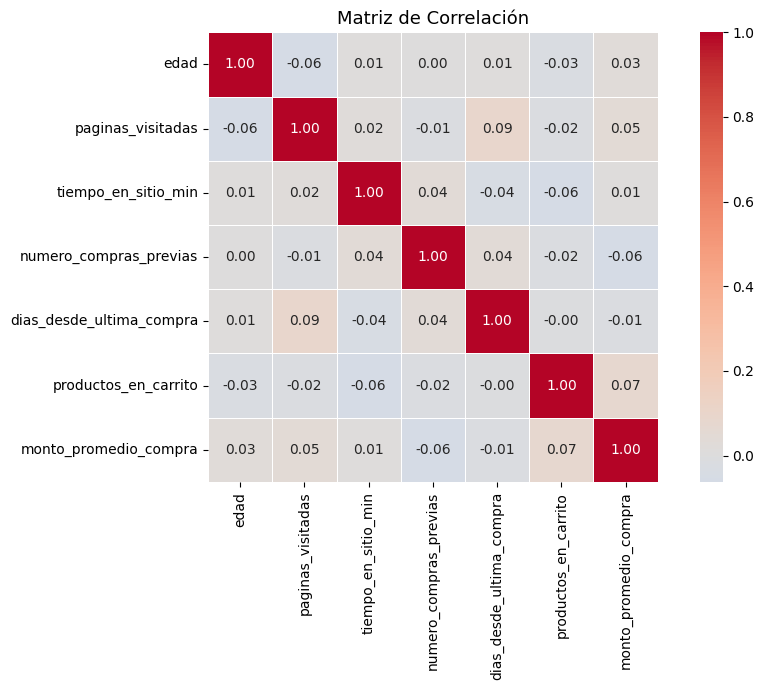

In [5]:
# Matriz de Correlación
plt.figure(figsize=(10, 7))
corr = df[['edad', 'paginas_visitadas', 'tiempo_en_sitio_min',
           'numero_compras_previas', 'dias_desde_ultima_compra',
           'productos_en_carrito', 'monto_promedio_compra']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)

plt.title('Matriz de Correlación', fontsize=13)
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

Ninguna variable numérica tiene correlación fuerte con 'monto_promedio_compra', ya que todos los valores son cercanos a 0:
- 'productos_en_carrito' (0.07) y 'paginas_visitadas' (0.05) son las que más se relacionan con la variable objetivo, aunque de forma muy débil.
- 'numero_compras_previas' (-0.06) tiene una leve relación negativa. Extrañamente, más compras previas no implica mayor gasto.

Entre las variables tampoco hay correlaciones fuertes entre sí (no hay multicolinealidad en el dataset).

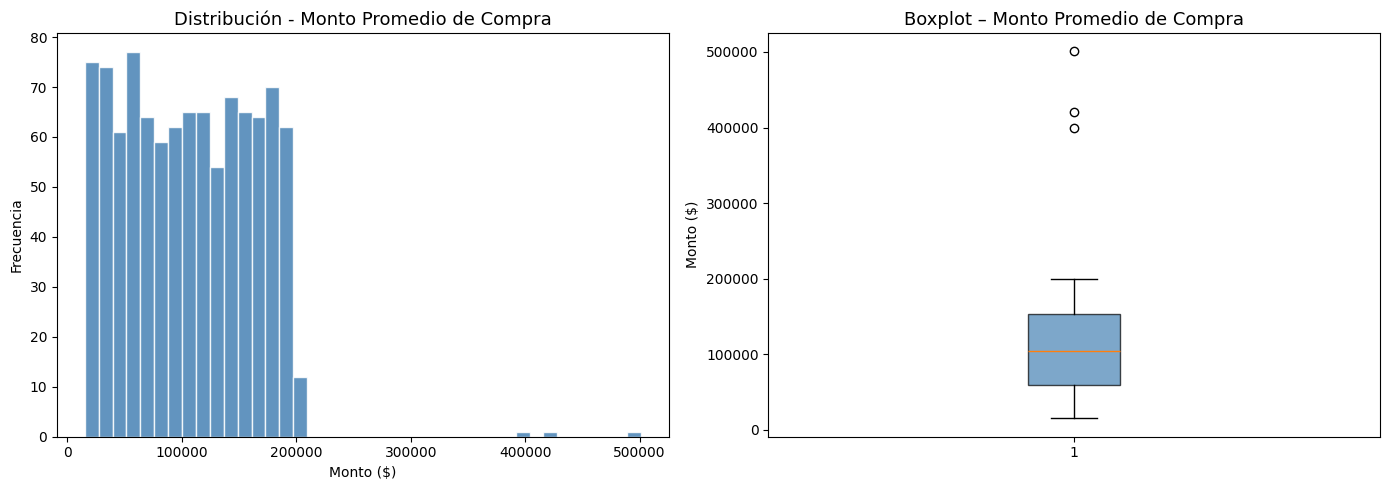

In [6]:
# Distribución de la variable objetivo Y = 'monto_promedio_compra'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['monto_promedio_compra'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución - Monto Promedio de Compra', fontsize=13)
axes[0].set_xlabel('Monto ($)'); axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['monto_promedio_compra'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot – Monto Promedio de Compra', fontsize=13)
axes[1].set_ylabel('Monto ($)')

plt.tight_layout()
plt.savefig('dist_target.png', dpi=150, bbox_inches='tight')
plt.show()

Interpretación:
- **Distribución:** El histograma sugiere que el “Monto Promedio de Compra” tiene una distribución sesgada o asimétrica, ya que hay pocos valores en los rangos más altos.
- **Outliers:** El boxplot muestra outliers en el extremo superior, lo que indica que algunas compras son significativamente más altas que el resto de las transacciones.

1. **Tratar valores nulos y outliers.**

In [7]:
# Crearemos una copia del Dataset Original para no perderlo y trabajar con la copia
df_temp = df.copy()

In [8]:
# Identificar Columnas Númericas
num = df_temp.select_dtypes(include=np.number).columns
num

Index(['edad', 'paginas_visitadas', 'tiempo_en_sitio_min',
       'numero_compras_previas', 'dias_desde_ultima_compra',
       'productos_en_carrito', 'uso_cupones', 'monto_promedio_compra'],
      dtype='object')

In [9]:
# Identificar Columnas Categóricas
cat = df_temp.select_dtypes(include='object').columns
cat

Index(['genero', 'zona', 'nivel_educacion', 'tipo_dispositivo'], dtype='object')

In [10]:
# Revisar cuántos Valores Nulos hay en las variables
nulos = df.isnull().sum()
nulos

,0
edad,0
genero,0
zona,7
nivel_educacion,11
paginas_visitadas,0
tiempo_en_sitio_min,13
numero_compras_previas,4
dias_desde_ultima_compra,5
productos_en_carrito,0
uso_cupones,0


In [11]:
# Imputación: Tratar Valores Nulos

from sklearn.impute import SimpleImputer

# Imputar los valores faltantes en las columnas numéricas con la Mediana (robusta a outliers)
imputer_num = SimpleImputer(strategy='median')
df_temp[num] = imputer_num.fit_transform(df_temp[num])

# Imputar los valores faltantes en columnas categóricas con la Moda
imputer_cat = SimpleImputer(strategy='most_frequent')
df_temp[cat] = imputer_cat.fit_transform(df_temp[cat])

# Verificar si ya no hay valores nulos
df_temp.isnull().sum()

,0
edad,0
genero,0
zona,0
nivel_educacion,0
paginas_visitadas,0
tiempo_en_sitio_min,0
numero_compras_previas,0
dias_desde_ultima_compra,0
productos_en_carrito,0
uso_cupones,0


In [12]:
# Identificar Outliers - Método del rango intercuartil (IQR)

# Identificar el primer, tercer cuartil y el IQR para cada columna numérica
Q1 = df_temp[num].quantile(0.25)
Q3 = df_temp[num].quantile(0.75)
IQR = Q3 - Q1

# Calculo de límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Detectar outliers
outliers = (df_temp[num] < limite_inferior) | (df_temp[num] > limite_superior)

# Contar los outliers por columna
outliers_count = outliers.sum()
display(outliers_count)

,0
edad,0
paginas_visitadas,0
tiempo_en_sitio_min,0
numero_compras_previas,0
dias_desde_ultima_compra,0
productos_en_carrito,0
uso_cupones,0
monto_promedio_compra,3


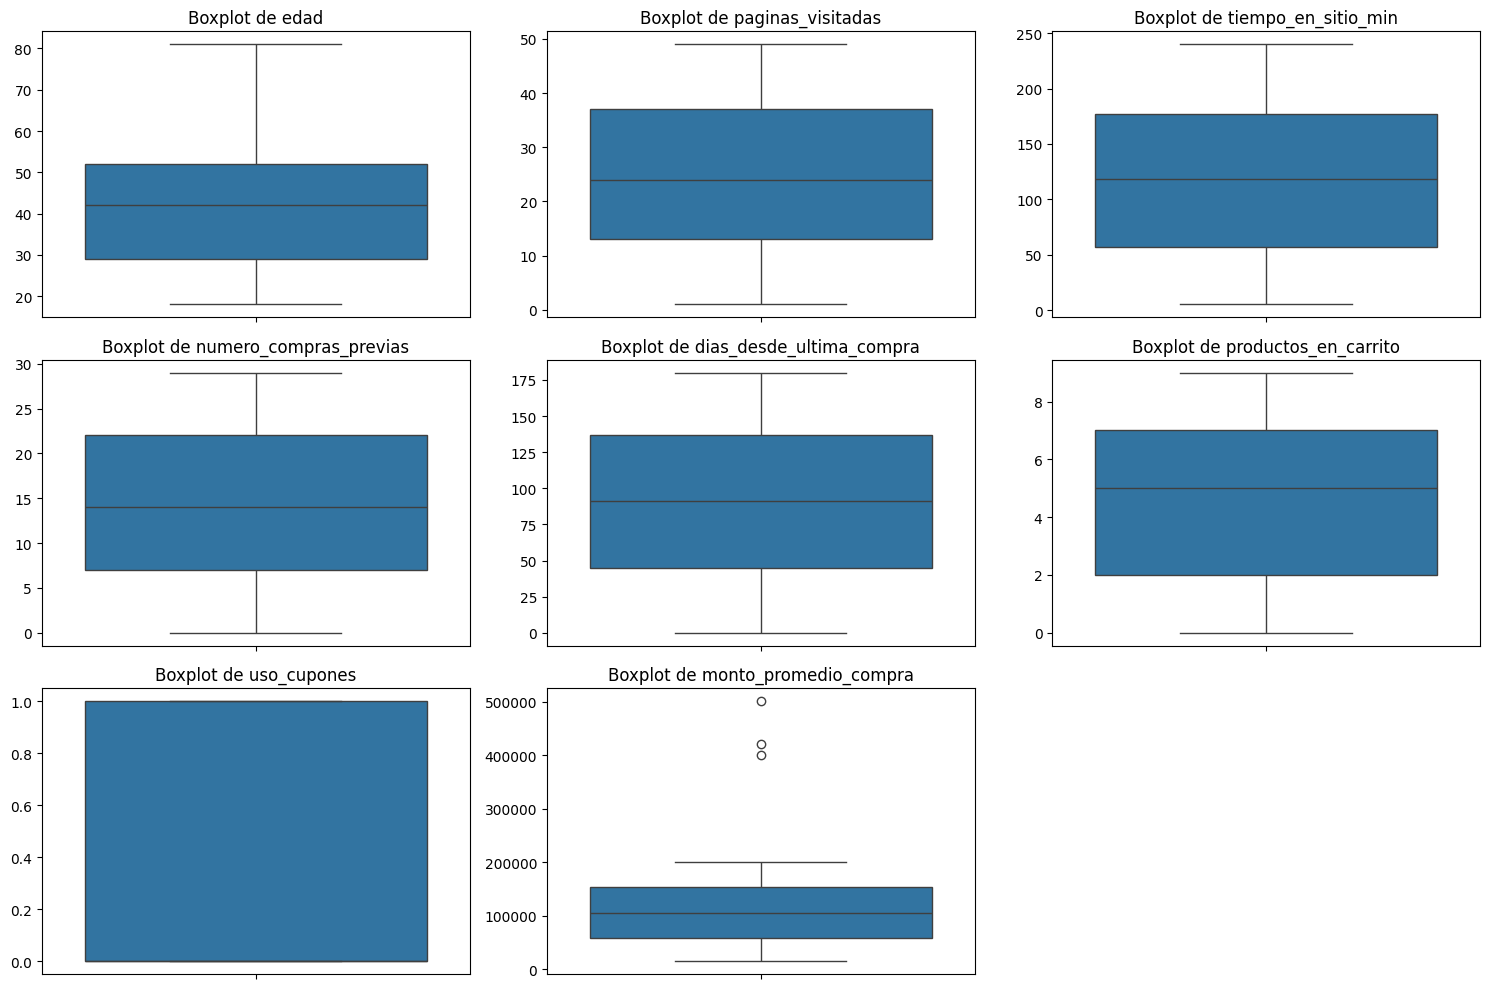

In [13]:
# Boxplot para confirmar visualmente columnas númericas con outliers
plt.figure(figsize=(15, 10))
for i, column in enumerate(num):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df_temp[column])
    plt.title(f'Boxplot de {column}')
    plt.ylabel('')
plt.tight_layout()
plt.savefig('boxplot_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Mostrar filas de outliers en Y
outliers_df = df_temp[outliers.any(axis=1)]
outliers_df

,edad,genero,zona,nivel_educacion,paginas_visitadas,tiempo_en_sitio_min,numero_compras_previas,dias_desde_ultima_compra,productos_en_carrito,uso_cupones,tipo_dispositivo,monto_promedio_compra
148,72.0,Femenino,Este,Posgrado,21.0,31.0,9.0,30.0,4.0,0.0,Celular,500990.0
984,80.0,Femenino,Centro,Universitario,10.0,211.0,21.0,115.0,5.0,0.0,Celular,400000.0
995,81.0,Masculino,Norte,Colegio/Liceo,29.0,118.0,3.0,119.0,6.0,1.0,Celular,420000.0


Existen diferentes estrategias de tratamiento de outliers, como la eliminación, la transformación matemática, Winsorización, aplicar modelos robustos o realizar un análisis separado. Él que hacer depende de cada situación.

En mi caso que estamos trabajando en una regresión supervisada donde la variable que tiene outliers es la variable objetivo de 'monto_promedio_compra'. No tratare los outliers, porque estos outliers son datos reales, no errores. Eliminarlos sesgaría el modelo hacia clientes de gasto medio y no podría predecir en el caso de clientes que gastan montos altos.

2. **Aplicar codificación a variables categóricas.**

In [15]:
# Codificación de Variables Categóricas con Variables Dummy
df_enc_temp = pd.get_dummies(df_temp,columns=['genero','zona','nivel_educacion','tipo_dispositivo'], drop_first=True).astype(float)

3. **Normalizar y/o estandarizar los datos.**

In [16]:
# Escalamiento de Variables Numéricas
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Separar variable objetivo (Y) de las características (X)
X_temp = df_enc_temp.drop('monto_promedio_compra', axis=1) # todas las variables, excepto 'monto_promedio_compra'
y_temp = df_enc_temp['monto_promedio_compra']  # Variable Objetivo

# Identificar columnas numéricas continuas a escalar
cols_escalar = ['edad', 'paginas_visitadas', 'tiempo_en_sitio_min',
                'numero_compras_previas', 'dias_desde_ultima_compra', 'productos_en_carrito']

La variable uso_cupones no fue escalada, porque es una variable binaria (0/1).

Existen dos métodos: Normalización o Estandarización.

In [17]:
# Normalización (Min-Max): rango [0, 1] y Sensible a valores atípicos
scaler_mm = MinMaxScaler()
X_norm = X_temp.copy()
X_norm[cols_escalar] = scaler_mm.fit_transform(X_temp[cols_escalar])

In [18]:
# Estandarización (Z-Score): media=0, desviación estándar=1 y Robusta ante valores atípicos
scaler_std = StandardScaler()
X_std = X_temp.copy()
X_std[cols_escalar] = scaler_std.fit_transform(X_temp[cols_escalar])

In [19]:
# Elección de Escalamiento
X = X_std.copy()
y = y_temp.copy()

StandardScaler usa media = 0 y desviación estándar = 1. Esto lo hace más robustas frente a valores atípicos como los detectados en monto_promedio_compra.

## **Lección 2 - *Nivel de Ajuste del Modelo y Validación Cruzada***

📌 **Objetivo:** Evaluar si el modelo está bien ajustado usando validación cruzada.

📍 **Tareas solicitadas en el ejercicio:**
1. Calcular y analizar los errores de entrenamiento y prueba.
2. Identificar sobreajuste y subajuste.
3. Implementar validación cruzada con K-Folds.

1. **Calcular y analizar los errores de entrenamiento y prueba.**

Se entrena un modelo de Regresión Lineal base para calcular el error sobre los datos de entrenamiento (train) y  prueba (test). Esta comparación permite diagnosticar el nivel de ajuste del modelo.

In [20]:
# División de los datos en entrenamiento (80%) y prueba (20%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Entrenamiento Modelo Regresión Lineal
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [22]:
# Predicciones sobre train y test
y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)

In [23]:
# Métricas de Evaluación - Modelo de Regresión Lineal
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train   = r2_score(y_train, y_pred_train)

mae_test  = mean_absolute_error(y_test,  y_pred_test)
mse_test  = mean_squared_error(y_test,  y_pred_test)
rmse_test  = np.sqrt(mse_test)
r2_test    = r2_score(y_test,  y_pred_test)

# Resultados de Métricas
print("\nError Cuadrático Medio (MSE):")
print(f"- MSE (Train): {mse_train:.2f}")
print(f"- MSE (Test): {mse_test:.2f}")

print("\nRaíz del Error Cuadrático Medio (RMSE):")
print(f"- RMSE (Train): {rmse_train:.2f}")
print(f"- RMSE (Test): {rmse_test:.2f}")

print("\nError Absoluto Medio (MAE):")
print(f"- MAE (Train): {mae_train:.2f}")
print(f"- MAE (Test): {mae_test:.2f}")

print("\nCoeficiente de Determinación (R²):")
print(f"- R² (Train): {r2_train:.4f}")
print(f"- R² (Test): {r2_test:.4f}")


Error Cuadrático Medio (MSE):
- MSE (Train): 3173430997.65
- MSE (Test): 3321920791.47

Raíz del Error Cuadrático Medio (RMSE):
- RMSE (Train): 56333.21
- RMSE (Test): 57636.11

Error Absoluto Medio (MAE):
- MAE (Train): 47378.32
- MAE (Test): 47866.19

Coeficiente de Determinación (R²):
- R² (Train): 0.0136
- R² (Test): 0.0046


**Interpretación de métricas — Regresión Lineal:**

- **MSE:** Muy alto por el efecto de los outliers en 'monto_promedio_compra'. No es la mejor métrica para evaluar el modelo, pero si para usarlo en comparación entre modelos.

- **RMSE:** El modelo se aleja en promedio $57.636 del valor real.

- **MAE:** Métrica más representativa dado los outliers en Y. En la mayoría de las predicciones el modelo se equivoca en promedio $47.866, sin verse distorsionado por los casos extremos.

- Con un **R² (Test)** de 0.0046, implica que el modelo explica menos del 1% de la varianza del gasto. Esto indica un subajuste.

2. **Identificar sobreajuste y subajuste.**

| Métrica | Resultado Train | Resultado Test |
|-|-|-|
| Raíz del Error Cuadrático Medio (RMSE) | 56333.21 | 57636.11|
| Coeficiente de Determinación (R²) | 0.0136 | 0.0046 |

Se analiza la diferencia entre RMSE train y RMSE test, ambos están altos, así que se identifica un **subajuste**. Esto significa que el modelo es demasiado simple para capturar los patrones.

Con un **R² (Test)** de 0.0046, implica que el modelo explica menos del 1% de la varianza del gasto. Esto tambien indica un subajuste.

3. **Implementar validación cruzada con K-Folds.**

In [24]:
from sklearn.model_selection import KFold, cross_val_score

# K-Fold con 5 particiones
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# RMSE y R² por fold (neg porque sklearn maximiza)
scores_rmse = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='neg_root_mean_squared_error')
rmse_folds = -scores_rmse  # Convertir a positivo
scores_r2   = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')

# Resultados por fold
resultados_cv = pd.DataFrame({
    'RMSE': rmse_folds,
    'R²': scores_r2
}, index=[f'Fold {i}' for i in range(1, 6)])

resultados_cv.loc['Promedio']  = resultados_cv.mean()
resultados_cv.loc['Desv. Est.'] = resultados_cv.std()
resultados_cv

,RMSE,R²
Fold 1,57636.106665,0.004606
Fold 2,62752.168000,-0.049324
Fold 3,54386.838571,-0.042565
Fold 4,55493.164977,-0.024157
Fold 5,57507.379933,-0.030275
Promedio,57555.131629,-0.028343
Desv. Est.,2874.293360,0.018705


El modelo es estable, ya que tiene una desviación estándar baja. Pero es inútil, ya que el R² promedio es negativo.

## **Lección 4 - *Regresiones***

📌 **Objetivo:** Implementar un modelo de regresión y comprender su funcionamiento.

📍 **Tareas solicitadas en el ejercicio:**
1. Entrenar un modelo de regresión lineal y uno polinomial.
2. Comparar su ajuste y precisión.
3. Interpretar los coeficientes del modelo.

1. **Entrenar un modelo de regresión lineal y uno polinomial.**

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Regresión Lineal
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predicciones de Regresión Lineal
y_pred_lr_train = lr.predict(X_train)
y_pred_lr_test  = lr.predict(X_test)

## Regresión Polinomial
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

# Entrenamiento
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

# Predicciones de Regresión Polinomial
y_pred_poly_train = lr_poly.predict(X_train_poly)
y_pred_poly_test  = lr_poly.predict(X_test_poly)

2. **Comparar su ajuste y precisión.**

In [26]:
# Evaluación por Métricas
def tabla_metricas(nombre, y_true, y_pred):
    return {
        'Modelo': nombre,
        'MAE':  mean_absolute_error(y_true, y_pred),
        'MSE':  mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²':   r2_score(y_true, y_pred)
    }

resultados_l4 = pd.DataFrame([
    tabla_metricas('Lineal — Train',      y_train, y_pred_lr_train),
    tabla_metricas('Lineal — Test',       y_test,  y_pred_lr_test),
    tabla_metricas('Polinomial — Train',  y_train, y_pred_poly_train),
    tabla_metricas('Polinomial — Test',   y_test,  y_pred_poly_test),
]).set_index('Modelo')

resultados_l4

,MAE,MSE,RMSE,R²
Modelo,,,,
Lineal — Train,47378.318862,3.173431e+09,56333.213983,0.013613
Lineal — Test,47866.194880,3.321921e+09,57636.106665,0.004606
Polinomial — Train,42584.895540,2.576010e+09,50754.412929,0.199307
Polinomial — Test,51760.999527,4.225747e+09,65005.742332,-0.266221


**Ajuste (train vs test):**
- Lineal: MAE train \$47.378 vs test \$47.866 — diferencia mínima. Por lo que, está bien ajustado pero con subajuste.
- Polinomial: MAE train \$42.584 vs test \$51.760. Existe una diferencia notable, así que sobreajuste.

**Precisión (qué modelo predice mejor):**
- El lineal es más consistente entre train y test aunque con bajo poder predictivo.
- El polinomial mejora en train (R² 0.19) pero empeora en test (R² -0.27), así la complejidad extra no ayuda a generalizar.

El MSE da números enormes, demostrando el impacto de los outliers en Y al elevar los errores al cuadrado. El RMSE al ser su raíz cuadrada, devuelve el error a la unidad original (\$), siendo más interpretable: el modelo lineal se equivoca en promedio \$56.333 en train y \$57.636 en test.

3. **Interpretar los coeficientes del modelo.**

In [27]:
# Coeficientes del Modelo lineal
coeficientes = pd.Series(lr.coef_, index=X_train.columns)
coef_ordenados = coeficientes.reindex(coeficientes.abs().sort_values(ascending=False).index)

print(f"Intercepto (β₀): ${lr.intercept_:,.2f}")
print("\nCoeficientes ordenados por importancia absoluta:")
display(coef_ordenados.to_frame(name='Coeficiente (β)').style.format('${:,.2f}'))

Intercepto (β₀): $106,144.82

Coeficientes ordenados por importancia absoluta:


,Coeficiente (β)
tipo_dispositivo_Tablet,"$5,885.65"
genero_Otro,"$4,943.41"
productos_en_carrito,"$3,852.56"
tipo_dispositivo_Computador,"$3,585.23"
uso_cupones,"$-3,464.65"
numero_compras_previas,"$-3,193.04"
zona_Oeste,"$2,815.63"
genero_Masculino,"$-2,289.76"
paginas_visitadas,"$1,984.59"
zona_Norte,"$-1,537.60"


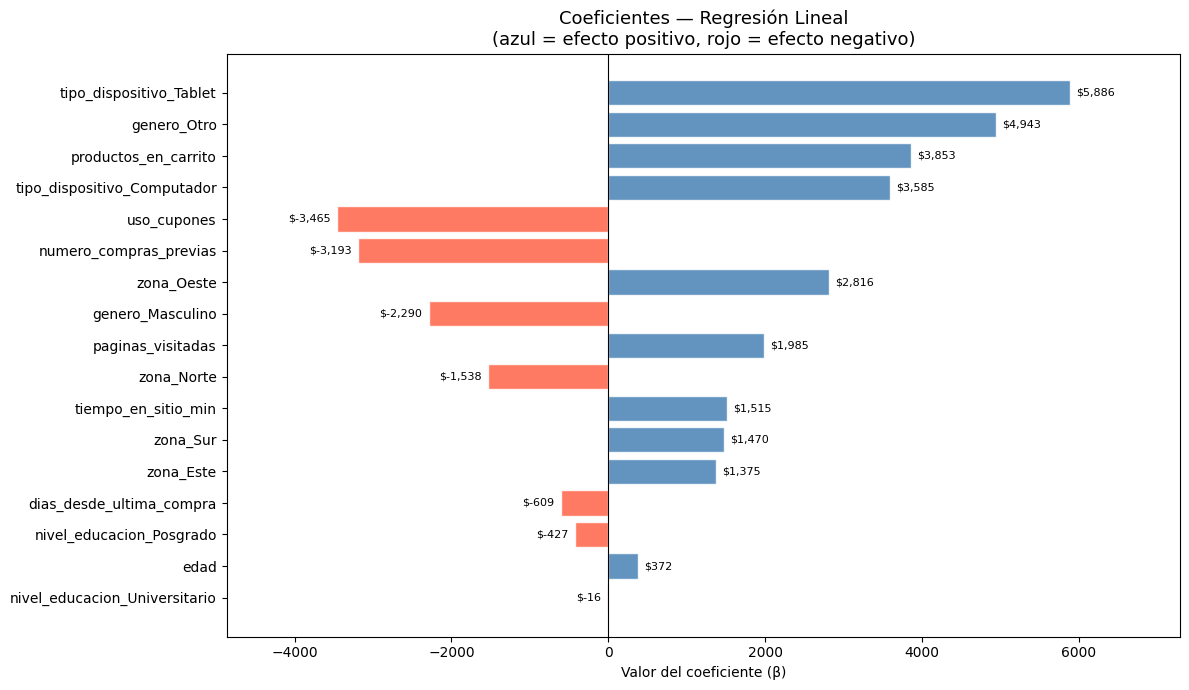

In [28]:
# Gráfico de coeficientes
colores = ['steelblue' if v > 0 else 'tomato' for v in coef_ordenados.values[::-1]]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(coef_ordenados.index[::-1], coef_ordenados.values[::-1],
               color=colores, edgecolor='white', alpha=0.85)

# Valores al lado de cada barra sin sobreposición
for bar, val in zip(bars, coef_ordenados.values[::-1]):
    offset = 80 if val >= 0 else -80
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', ha=ha, fontsize=8)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes — Regresión Lineal\n(azul = efecto positivo, rojo = efecto negativo)', fontsize=13)
ax.set_xlabel('Valor del coeficiente (β)')

# Margen extra a la izquierda para evitar sobreposición con los nombres
ax.margins(x=0.15)

plt.tight_layout()
plt.savefig('coeficientes_lr.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:**

El gráfico presenta coeficientes ordenados por importancia absoluta. Cada coeficiente indica cuánto aumenta/disminuye el 'monto_promedio_compra' por cada unidad adicional de esa variable (manteniendo las demás constantes).

- **Coeficiente positivo (azul):** esa variable incrementa el gasto esperado.
- **Coeficiente negativo (rojo):** esa variable lo reduce.
- **Coeficiente cercano a 0:** la variable prácticamente no influye en la predicción.

## **Lección 5 - *Algoritmos de Clasificación***

📌 **Objetivo:** Entender diferencias conceptuales con clasificación.

📍 **Tareas solicitadas en el ejercicio:**
1. Analizar por qué un problema de clasificación no es adecuado para esta tarea.
2. Implementar un clasificador KNN sobre un subconjunto simulado.
3. Comparar su comportamiento frente al modelo regresivo.

1. **Analizar por qué un problema de clasificación no es adecuado para esta tarea.**

La clasificación es un tipo de problema en el aprendizaje supervisado donde el
objetivo es predecir una categoría o clase para un conjunto de datos de entrada.
A diferencia de las tareas de regresión, que predicen un valor numérico continuo,
en clasificación el resultado es una etiqueta discreta.

En este caso la variable objetivo 'monto_promedio_compra' es un **valor numérico continuo** (entre $15.118 y $500.990) y el objetivo del análisis de caso es predecir valores numéricos, no categorías. El modelo entrenado utilizará estos datos para hacer predicciones sobre el gasto de futuros clientes.

2. **Implementar un clasificador KNN sobre un subconjunto simulado.**

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Crear las Categorías Ficticias
# Bajo: $0 a $70.000
# Medio: $70.000 a $150.000
# Alto: más de $150.000
bins   = [0, 70000, 150000, float('inf')]
labels = ['Bajo', 'Medio', 'Alto']

In [30]:
# Convertir Y continuo a categorías
y_cat_train = pd.cut(y_train, bins=bins, labels=labels)
y_cat_test  = pd.cut(y_test,  bins=bins, labels=labels)

In [31]:
# Entrenamiento del clasificador KNN (k=5)
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_cat_train)

KNeighborsClassifier()

In [32]:
# Predicción
y_pred_knn = knn_clf.predict(X_test)

In [33]:
# Evaluación de Métricas
print(f"Accuracy KNN Clasificador (k=5): {accuracy_score(y_cat_test, y_pred_knn):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_cat_test, y_pred_knn))

Accuracy KNN Clasificador (k=5): 0.3650

Reporte de clasificación:
              precision    recall  f1-score   support

        Alto       0.28      0.36      0.31        53
        Bajo       0.33      0.36      0.34        61
       Medio       0.50      0.37      0.43        86

    accuracy                           0.36       200
   macro avg       0.37      0.36      0.36       200
weighted avg       0.39      0.36      0.37       200



- **Exactitud (Accuracy)**: Un Accuracy KNN Clasificador de 0.365 nos indica que las predicciones de categoría del modelo solo acierta el 36,5% de los casos.

  El Reporte de Clasificación desglosa el desempeño por cada categoría mostrando precisión, recall y F1-score para Bajo, Medio y Alto por separado.

- **Precisión (Precision)**: ¿cuántos eran realmente esa categoría? **Medio (0.50)** es la categoría más fácil de predecir. La peor predicción es **Alto**, así que el modelo prácticamente no identifica a los clientes de alto valor.

- **Sensibilidad (Recall):** Indica la capacidad del modelo para identificar correctamente las observaciones positivas, en este caso entre 36% y 37%.


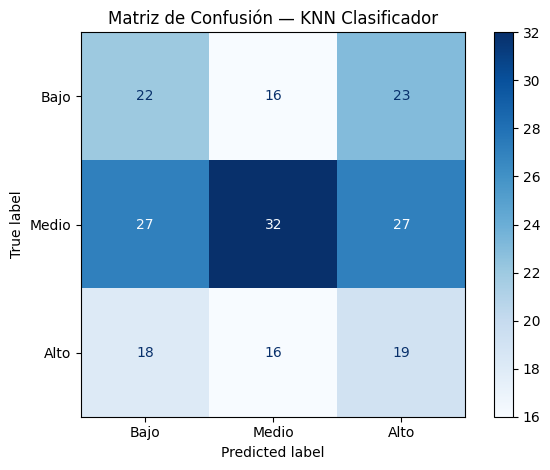

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_cat_test, y_pred_knn, labels=['Bajo', 'Medio', 'Alto'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bajo', 'Medio', 'Alto'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — KNN Clasificador')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

**Matriz de Confusión:**

En la diagonal están los aciertos (22, 32, 19) y fuera de la diagonal están los errores entre la categoría real (filas) y la categoría predicha (columnas). Por ejemplo, en la categoría 'Bajo' existen 61 casos reales y predijo bien 22, confundió 16 con 'Medio' y 23 con 'Alto', equivocándose en más de la mitad.

Por lo tanto, el modelo no logra distinguir bien ninguna categoría — los errores están distribuidos de forma casi uniforme en todas las celdas, lo que indica que el clasificador prácticamente adivina.



3. **Comparar su comportamiento frente al modelo regresivo**

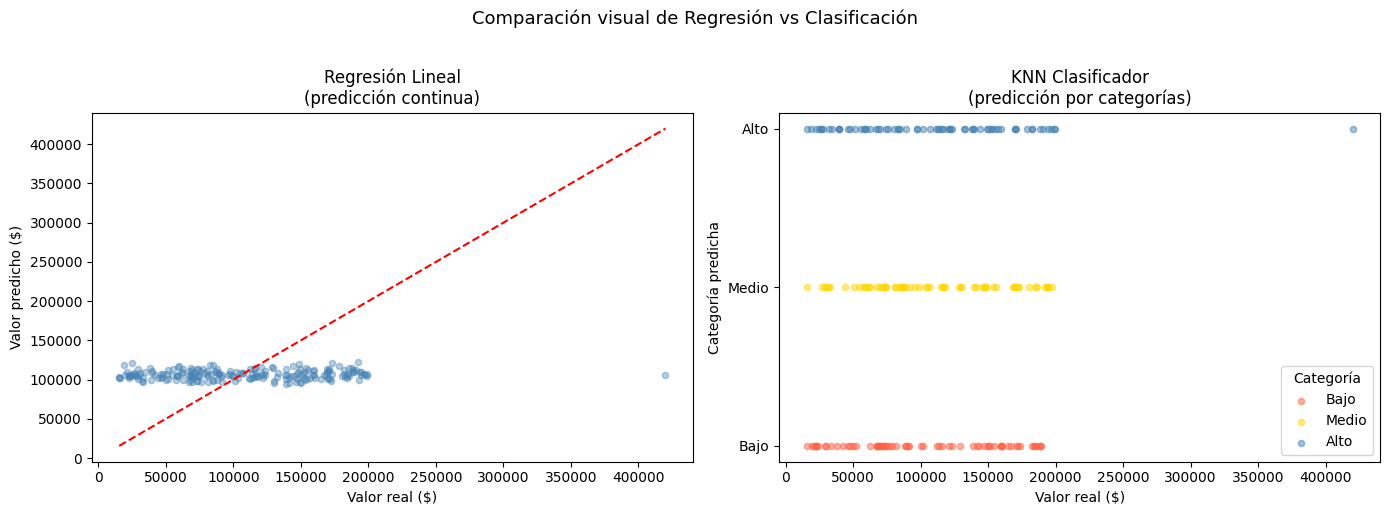

In [35]:
# Comparación visual: predicciones del regresor vs etiquetas del clasificador
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: regresión lineal (valores continuos)
axes[0].scatter(y_test, y_pred_lr_test, alpha=0.4, color='steelblue', s=20)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_title('Regresión Lineal\n(predicción continua)', fontsize=12)
axes[0].set_xlabel('Valor real ($)'); axes[0].set_ylabel('Valor predicho ($)')

# Panel derecho: KNN clasificador (etiquetas discretas)
colores_cat = {'Bajo': 'tomato', 'Medio': 'gold', 'Alto': 'steelblue'}
for cat in labels:
    mask = np.array(y_pred_knn) == cat
    axes[1].scatter(
        y_test.values[mask], [cat]*mask.sum(),
        color=colores_cat[cat], alpha=0.5, s=20, label=cat
    )
axes[1].set_title('KNN Clasificador\n(predicción por categorías)', fontsize=12)
axes[1].set_xlabel('Valor real ($)'); axes[1].set_ylabel('Categoría predicha')
axes[1].legend(title='Categoría')

plt.suptitle('Comparación visual de Regresión vs Clasificación', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('regresion_vs_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

**Regresión Lineal:**
Los puntos se concentran entre \$80.000 y \$120.000 sin importar el valor real, lo que confirma el subajuste: el modelo tiende a predecir siempre cerca del promedio  y no logra seguir la línea diagonal roja (predicción perfecta).

**KNN Clasificador:**
Se ven claramente las 3 líneas horizontales. Todos los clientes predichos como  "Alto" quedan en la misma fila, sin importar si su monto real es \$20.000 o \$400.000. Significa que clientes de gasto bajo quedan clasificados como alto, el peor error posible para el negocio. Esto demuestra visualmente la pérdida de información al utilizar ente modelo.


Aunque la regresión lineal tampoco predice bien (subajuste), al menos intenta estimar el monto exacto. La clasificación directamente colapsa toda la información en 3 etiquetas, haciendo imposible distinguir entre un cliente de \$71.000 y uno de \$149.000 — ambos son simplemente "Medio".

## **Lección 6 - *Métricas de Desempeño***

📌 **Objetivo:** Evaluar objetivamente el rendimiento del modelo regresivo.

📍 **Tareas solicitadas en el ejercicio:**
1. Calcular MAE, MSE, RMSE y R².
2. Interpretar resultados y comparar modelos entrenados.
3. Elaborar una tabla comparativa de métricas.

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Función Tabla Métricas (reutilizable)
def tabla_metricas(nombre, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Modelo': nombre, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2}

# Construcción de Tabla Resumen
# Calcular métricas para todos los modelos entrenados hasta ahora
tabla_l6 = pd.DataFrame([
    tabla_metricas('Regresión Lineal',            y_test, y_pred_lr_test),
    tabla_metricas('Regresión Polinomial',  y_test, y_pred_poly_test),
]).set_index('Modelo')

# Formato lindo de Tabla Resumen
display(tabla_l6.style
        .format({'MAE': '${:,.0f}', 'MSE': '{:,.0f}', 'RMSE': '${:,.0f}', 'R²': '{:.4f}'})
        .background_gradient(cmap='RdYlGn', subset=['R²'])
        .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE'])
        .set_caption('Tabla comparativa de Métricas'))

,MAE,MSE,RMSE,R²
Modelo,,,,
Regresión Lineal,"$47,866","3,321,920,791","$57,636",0.0046
Regresión Polinomial,"$51,761","4,225,746,536","$65,006",-0.2662


Como el objetivo es comparar modelos entre sí, no diagnosticar ajuste, solo se evaluó Test (no con Train). Ya que el conjunto de prueba es el que refleja cómo se comporta el modelo con datos nuevos.

**Interpretación:**

La Regresión Lineal supera al modelo Polinomial en todas las métricas:

- **MAE:** El modelo lineal se equivoca \$47.866 por predicción. El polinomial se equivoca en promedio \$3.895 más por predicción.
- **MSE:** Los valores enormes (3.3 y 4.2 mil millones) confirman el impacto de los outliers en Y al elevar los errores al cuadrado.
- **RMSE:** Al penalizar errores grandes, un RMSE alto indica que el modelo comete errores graves en algunos clientes. El polinomial comete errores más graves.
- **R²:** Un R² cercano a 0 indica que el modelo no está explicando la varianza del gasto. El polinomial explica negativamente la varianza, es decir, predice peor que usar el promedio como predicción fija.

## **Lección 7 - *Optimización del Modelo***

📌 **Objetivo:** Mejorar el desempeño general del modelo mediante técnicas de ajuste.

📍 **Tareas solicitadas en el ejercicio:**
1. Realizar ingeniería de características.
2. Ajustar hiperparámetros usando GridSearchCV.
3. Aplicar regularización (Ridge, Lasso) y observar su impacto.

1. **Realizar ingeniería de características.**

La matriz de correlación mostró que ninguna variable tiene correlación fuerte con la variable objetivo de forma individual. Así que se utilizará la ingeniería de características para crear variables que combinen información de varias columnas, capturando relaciones que las variables originales solas no pueden expresar.

Se crearan 4 nuevas variables que combinan información de varias columnas:
- engagement = paginas_visitadas × tiempo_en_sitio (nivel de interés real del cliente)
-	ratio_conversion = compras_previas / (paginas + 1) (eficiencia de conversión por visita)
- recencia_inv = 1 / (dias_ultima_compra + 1) (clientes recientes tienen más valor — RFM)
- carrito_cupon = productos_carrito × uso_cupones (patrón combinado de comportamiento)

In [37]:
# Crear nuevas variables que capturen relaciones no lineales

# Partir del dataset ya escalado
X_fe = X.copy()

# Interacción: páginas visitadas × tiempo en sitio
X_fe['engagement'] = X_fe['paginas_visitadas'] * X_fe['tiempo_en_sitio_min']

# Ratio de conversión: compras previas por visita
X_fe['ratio_conversion'] = X_fe['numero_compras_previas'] / (X_fe['paginas_visitadas'] + 1)

# Recencia inversa: clientes que compraron recientemente tienen mayor probabilidad de volver
# RFM (Recency, Frequency, Monetary)
# Recencia mide hace cuánto tiempo compró un cliente por última vez.
# En el dataset tenemos dias_desde_ultima_compra — a mayor número, más tiempo pasó sin comprar.
# Pero para predecir gasto, lo que importa es lo contrario.
X_fe['recencia_inv'] = 1 / (X_fe['dias_desde_ultima_compra'] + 1)

# Interacción: productos en carrito × uso de cupones (comportamiento de compra)
X_fe['carrito_cupon'] = X_fe['productos_en_carrito'] * X_fe['uso_cupones']

In [38]:
# Evaluar si las nuevas variables mejoran el modelo lineal base
X_fe_train, X_fe_test, _, _ = train_test_split(X_fe, y, test_size=0.2, random_state=42)

# Entrenamiento de Modelo Lineal (21 variables = 17 originales + 4 nuevas)
lr_fe = LinearRegression()
lr_fe.fit(X_fe_train, y_train)
y_pred_fe_test = lr_fe.predict(X_fe_test)

# Métricas del Modelo con y sin ingeniería de características
comparacion_fe = pd.DataFrame([
    tabla_metricas('Sin ingeniería (base)', y_test, y_pred_lr_test),
    tabla_metricas('Con ingeniería',        y_test, y_pred_fe_test),
]).set_index('Modelo')

display(comparacion_fe.style
        .format({'MAE': '${:,.0f}', 'MSE': '{:,.0f}', 'RMSE': '${:,.0f}', 'R²': '{:.4f}'})
        .background_gradient(cmap='RdYlGn', subset=['R²'])
        .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE'])
        .set_caption('Comparación — Regresión Lineal CON y SIN ingeniería de características'))

,MAE,MSE,RMSE,R²
Modelo,,,,
Sin ingeniería (base),"$47,866","3,321,920,791","$57,636",0.0046
Con ingeniería,"$47,698","3,306,476,043","$57,502",0.0092


Las cuatro nuevas variables generaron una mejora leve en el modelo:
- **MAE**: bajó → el error promedio se redujo $168 por predicción.
- **RMSE**: bajó → menos errores graves.
- **R²**: aumentó → el modelo duplicó su capacidad explicativa, aunque sigue siendo muy baja.

Esto indica que las relaciones no lineales  que intentamos capturar con 'engagement', 'ratio_conversion', 'recencia_inv' y 'carrito_cupon' no son suficientes para este modelo.

La ingeniería de características ayudó, pero si el algoritmo inicial tiene limitaciones estructurales (como la regresión lineal ante patrones no lineales), la mejora tiene un techo. Esto justifica avanzar hacia **GridSearchCV con regularización y Gradient Boosting**.

2. **Ajustar hiperparámetros usando GridSearchCV.**

**GridSearchCV** evalúa todas las combinaciones posibles de hiperparámetros usando validación cruzada, y devuelve automáticamente la configuración con mejor desempeño.

Se aplica sobre **Ridge**, ya que es el modelo regularizado visto en el curso y cuenta con el hiperparámetro 'alpha' que controla la fuerza de la regularización. Un alpha bajo implica que no hay regularización y un alpha alto significa una existe una regularización fuerte.

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# GridSearchCV con Ridge — buscando el alpha óptimo

# Alphas: sin regularización (alpha bajo) y regularización fuerte (alpha alto)
param_grid_ridge = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

# GridSearchCV
grid_ridge = GridSearchCV(
    Ridge(), param_grid_ridge,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
grid_ridge.fit(X_fe_train, y_train)

print("Resultados GridSearchCV — Ridge:")
print(f"  Mejor alpha:     {grid_ridge.best_params_['alpha']}")
print(f"  RMSE CV (train): ${-grid_ridge.best_score_:,.0f}")

Resultados GridSearchCV — Ridge:
  Mejor alpha:     1000
  RMSE CV (train): $56,947


In [40]:
# Evaluar en test con el mejor modelo
y_pred_ridge_opt = grid_ridge.best_estimator_.predict(X_fe_test) # predicción

resultados_ridge = pd.DataFrame([
    tabla_metricas('Ridge Optimizado — Test', y_test, y_pred_ridge_opt),
]).set_index('Modelo')

display(resultados_ridge.style
        .format({'MAE': '${:,.0f}', 'MSE': '{:,.0f}', 'RMSE': '${:,.0f}', 'R²': '{:.4f}'})
        .background_gradient(cmap='RdYlGn', subset=['R²'])
        .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE']))

,MAE,MSE,RMSE,R²
Modelo,,,,
Ridge Optimizado — Test,"$47,748","3,288,824,906","$57,348",0.0145


- **RMSE CV: \$56.947** → error estimado en validación cruzada.
- **RMSE Test: \$57.348** → error real sobre datos nuevos. Es muy similar al RMSE CV, lo que confirma que el modelo generaliza bien y los resultados de la validación cruzada son confiables.

- **R² Test: 0.0145** → el modelo explica el 1.45% de la varianza del gasto. Aunque es bajo, representa una mejora respecto a la Regresión Lineal base (R² = 0.0046).

- La regularización fuerte (α=1000) logró estabilizar el modelo y mejorar su capacidad de generalización.

3. **Aplicar regularización (Ridge, Lasso) y observar su impacto.**

**Ridge** ya fue optimizado con GridSearchCV en el punto anterior (mejor α=1000, RMSE Test $57.348, R² 0.0145).

A continuación se aplica **Lasso** con los mismos alphas para comparar el impacto de ambas técnicas de regularización.

In [41]:
from sklearn.linear_model import Lasso

# Probar distintos alphas en Lasso
alphas = [0.01, 0.1, 1, 10, 100, 1000]
resultados_lasso = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_fe_train, y_train) # entrenamiento
    y_pred = lasso.predict(X_fe_test) # predicción para evaluar modelo
    resultados_lasso.append(tabla_metricas(f'Lasso (α={alpha})', y_test, y_pred))

# Métricas
df_lasso = pd.DataFrame(resultados_lasso).set_index('Modelo')

display(df_lasso.style
        .format({'MAE': '${:,.0f}', 'MSE': '{:,.0f}', 'RMSE': '${:,.0f}', 'R²': '{:.4f}'})
        .background_gradient(cmap='RdYlGn', subset=['R²'])
        .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE'])
        .set_caption('Lasso — Comparación por alpha'))

,MAE,MSE,RMSE,R²
Modelo,,,,
Lasso (α=0.01),"$47,698","3,306,474,768","$57,502",0.0092
Lasso (α=0.1),"$47,698","3,306,463,296","$57,502",0.0092
Lasso (α=1),"$47,698","3,306,348,466","$57,501",0.0093
Lasso (α=10),"$47,696","3,305,325,611","$57,492",0.0096
Lasso (α=100),"$47,700","3,299,241,709","$57,439",0.0114
Lasso (α=1000),"$47,686","3,274,697,007","$57,225",0.0188


Ambos modelos alcanzaron su mejor desempeño con alpha = 1000, la regularización más fuerte de las probadas.

Un alpha tan alto indica que el modelo necesita regularización fuerte para  estabilizarse — sin ella, los coeficientes crecen demasiado tratando de ajustarse a un dataset con señal predictiva débil.

**Ridge** penaliza coeficientes grandes reduciéndolos, pero nunca los lleva exactamente a 0 — todas las variables siguen participando en la predicción. **Lasso** con alpha alto lleva varios coeficientes a exactamente 0, eliminando variables que no aportan. Esto actúa como una selección automática de variables — con tantas variables de baja correlación con el objetivo, simplificar el modelo ayuda a generalizar mejor (subajuste).

**Comparado con la Regresión Lineal base (R² = 0.0046):**
- Lasso mejora el R² en ~4 veces (0.0046 → 0.0188)
- Ridge mejora el R² en ~3 veces (0.0046 → 0.0145)

Aunque la mejora absoluta sigue siendo modesta, confirma que  la regularización aporta valor en este dataset.

## **Lección 8 - *Algoritmos de Boosting***

📌 **Objetivo:** Implementar un modelo avanzado usando Gradient Boosting.

📍 **Tareas solicitadas en el ejercicio:**
1. Entrenar un modelo con GradientBoostingRegressor.
2. Comparar desempeño frente al modelo lineal optimizado.
3. Explicar ventajas y limitaciones del enfoque ensemble.

1. **Entrenar un modelo con GradientBoostingRegressor.**

In [42]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Entrenamiento base de Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42)

# Entrenamiento y predicciones
gb.fit(X_fe_train, y_train)
y_pred_gb_train = gb.predict(X_fe_train)
y_pred_gb_test  = gb.predict(X_fe_test)

# Métricas train vs test
print("GradientBoostingRegressor — Resultados Train vs Test:")
resultados_gb_base = pd.DataFrame([
    tabla_metricas('GB Base — Train', y_train, y_pred_gb_train),
    tabla_metricas('GB Base — Test',  y_test,  y_pred_gb_test),
]).set_index('Modelo')

display(resultados_gb_base.style
        .format({'MAE': '${:,.0f}', 'MSE': '{:,.0f}', 'RMSE': '${:,.0f}', 'R²': '{:.4f}'})
        .background_gradient(cmap='RdYlGn', subset=['R²'])
        .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE']))

GradientBoostingRegressor — Resultados Train vs Test:


,MAE,MSE,RMSE,R²
Modelo,,,,
GB Base — Train,"$26,084","963,472,395","$31,040",0.7005
GB Base — Test,"$48,370","3,176,605,970","$56,361",0.0481


La brecha entre Train y Test es muy notable en todas las métricas:
- **MAE** y **RMSE**: El modelo predice casi el doble de bien en entrenamiento que en prueba.
- **R² Train: 0.7005** → El modelo explica el 70% de la varianza en entrenamiento, una mejora enorme respecto a la Regresión Lineal (0.013).
- **R² Test: 0.0481** → En datos nuevos solo explica el 4.8% — hay una brecha considerable entre train y test.

Dada las métricas, el modelo presenta un sobreajuste, significa que memorizó demasiado los datos de entrenamiento y no generaliza bien. Esto puede ser por los hiperparámetros iniciales (n_estimators=200, max_depth=4).

Así que se realizará un **GridSearchCV** para encontrar hiperparámetros más simples que reduzcan la brecha entre Train y Test.

In [43]:
## Optimización de hiperparámetros con GridSearchCV

# Hiperparametrización
param_grid_gb = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 4, 5],
    'subsample':     [0.8, 1.0]
}

# GridSearchCV
grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42), param_grid_gb,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)

# Entrenamiento
grid_gb.fit(X_fe_train, y_train)

print("Mejores hiperparámetros para GradientBoosting:")
print(f"  {grid_gb.best_params_}")
print(f"  RMSE CV: ${-grid_gb.best_score_:,.0f}")

Mejores hiperparámetros para GradientBoosting:
  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
  RMSE CV: $58,078


De todas las combinaciones probadas, los mejores hiperparámetros fueron 'learning_rate: 0.05', 'max_depth: 3', 'n_estimators: 100' y 'subsample: 1.0'. Esta combinación genera un **RMSE CV: \$58.078**. Esto es el error promedio de los 5 folds en validación. Es levemente mayor al RMSE Test (\$56.361).

In [44]:
# Predicciones con Modelo Optimizado
gb_opt = grid_gb.best_estimator_
y_pred_gb_opt = gb_opt.predict(X_fe_test)

# Métricas
resultados_gb_opt = pd.DataFrame([
    tabla_metricas('GB Base — Train', y_train, y_pred_gb_train), #
    tabla_metricas('GB Base — Test',  y_test,  y_pred_gb_test), #
    tabla_metricas('GB Optimizado — Test', y_test, y_pred_gb_opt), # optimizado
]).set_index('Modelo')

print("GradientBoostingRegressor — Resultados:")
display(resultados_gb_opt.style
        .format({'MAE': '${:,.0f}', 'MSE': '{:,.0f}', 'RMSE': '${:,.0f}', 'R²': '{:.4f}'})
        .background_gradient(cmap='RdYlGn', subset=['R²'])
        .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE']))

GradientBoostingRegressor — Resultados:


,MAE,MSE,RMSE,R²
Modelo,,,,
GB Base — Train,"$26,084","963,472,395","$31,040",0.7005
GB Base — Test,"$48,370","3,176,605,970","$56,361",0.0481
GB Optimizado — Test,"$46,883","2,981,842,928","$54,606",0.1065


- **RMSE:** bajó \$1.755 → el modelo optimizado comete errores más pequeños.
- **R²:** mejoró de 0.0481 a 0.1065 → más del doble de capacidad explicativa.
- Con R² = 0.1065, el GradientBoosting Optimizado es el mejor modelo del proyecto — explica el 10.65% de la varianza del gasto, superando ampliamente a todos los modelos lineales evaluados (máximo R² = 0.0197 con Lasso).

2. **Comparar desempeño frente al modelo lineal optimizado.**

In [45]:
# Predicción con mejor alpha=1000 en Lasso
mejor_lasso = Lasso(alpha=1000, max_iter=10000).fit(X_fe_train, y_train)
y_pred_lasso_final = mejor_lasso.predict(X_fe_test)

# Tabla comparativa final — todos los modelos del proyecto
tabla_final = pd.DataFrame([
    tabla_metricas('Reg. Lineal',        y_test, y_pred_lr_test),
    tabla_metricas('Reg. Polinomial',    y_test, y_pred_poly_test),
    tabla_metricas('Ridge (α=1000)',     y_test, y_pred_ridge_opt),
    tabla_metricas('Lasso (α=1000)',     y_test, y_pred_lasso_final),
    tabla_metricas('Gradient Boosting',  y_test, y_pred_gb_opt),
]).set_index('Modelo')

display(tabla_final.style
        .format({'MAE': '${:,.0f}', 'MSE': '{:,.0f}', 'RMSE': '${:,.0f}', 'R²': '{:.4f}'})
        .background_gradient(cmap='RdYlGn', subset=['R²'])
        .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE'])
        .set_caption('Tabla Comparativa de los Modelos Aplicados (Test)'))

,MAE,MSE,RMSE,R²
Modelo,,,,
Reg. Lineal,"$47,866","3,321,920,791","$57,636",0.0046
Reg. Polinomial,"$51,761","4,225,746,536","$65,006",-0.2662
Ridge (α=1000),"$47,748","3,288,824,906","$57,348",0.0145
Lasso (α=1000),"$47,686","3,274,697,007","$57,225",0.0188
Gradient Boosting,"$46,883","2,981,842,928","$54,606",0.1065


> ***Nota:** La tabla incluye únicamente métricas sobre el conjunto de **prueba (Test)**, ya que el objetivo es comparar el desempeño real de cada modelo sobre datos nuevos. Las métricas de entrenamiento (Train) se utilizaron en cada lección para diagnosticar sobreajuste/subajuste, no para comparar modelos entre sí.*

Como se aprecia en la tabla, Gradient Boosting es el mejor modelo en todas las métricas:
- **MAE más bajo (\$46.883)** → menor error promedio por predicción.
- **MSE más bajo (2.981.842.928)** → menor impacto de outliers.
- **RMSE más bajo (\$54.606)** → menos errores graves.
- **R² más alto (0.1065)** → único modelo que supera el 10% de varianza explicada.

Aunque el R² general sigue siendo moderado, esto refleja que el gasto en e-commerce es difícil de predecir solo con variables demográficas y de comportamiento básico. Gradient Boosting es claramente la mejor herramienta disponible con estos datos.

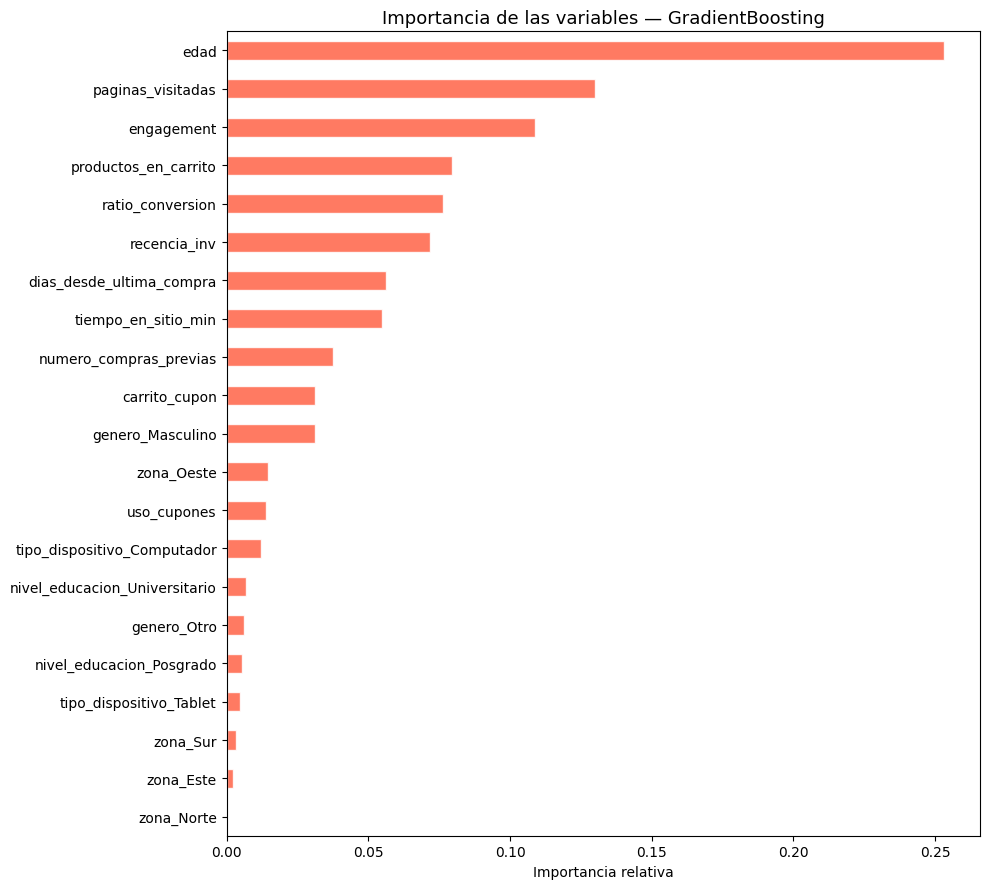

In [46]:
# Importancia de las variables — GradientBoosting
importancias = pd.Series(gb_opt.feature_importances_, index=X_fe_train.columns)
importancias_ord = importancias.sort_values(ascending=False)

plt.figure(figsize=(10, 9))
importancias_ord[::-1].plot(kind='barh', color='tomato', edgecolor='white', alpha=0.85)
plt.title('Importancia de las variables — GradientBoosting', fontsize=13)
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('feature_importance_gb.png', dpi=150, bbox_inches='tight')
plt.show()

De las 21 variables, la **edad**, las **paginas_visitadas** y el **engagement** son las variables más influyentes.

Las cuatro nuevas variables aparecen en:
- 'engagement' → 3° lugar
- 'ratio_conversion' → 5° lugar
- 'recencia_inv' → 6° lugar
- 'carrito_cupon' → 10° lugar

Esto confirma que la ingeniería de características aportó valor real al modelo.

**Variables de bajo impacto:**
Las variables de 'zona_Norte', 'zona_Este', 'zona_Sur', 'tipo_dispositivo_Tablet' y
'nivel_educacion_Posgrado' tienen barras casi invisibles, por lo que, prácticamente no influyen en el gasto.

Para el negocio, los esfuerzos de personalización deberían focalizarse en la **edad del cliente** y su **nivel de engagement** (páginas visitadas y tiempo en sitio), ya que son las señales más fuertes para predecir cuánto va a gastar.

3. **Explicar ventajas y limitaciones del enfoque Ensemble.**

Gradient Boosting es un método de ensamble (ensemble) — es decir, combina múltiples modelos débiles para formar uno fuerte.

En el caso de Gradient Boosting específicamente:
- Entrena muchos árboles de decisión pequeños (modelos débiles) de forma secuencial.
- Cada árbol nuevo corrige los errores del anterior.
- Al final, la predicción es la suma de todos los árboles juntos.

El resultado es un modelo mucho más poderoso que cualquier árbol individual — de ahí el concepto de "ensamble": la unión de muchos modelos débiles forma uno fuerte.

**Ventajas:**
- **Alta precisión:** genera modelos altamente precisos gracias a su naturaleza secuencial y correctiva, superando consistentemente a modelos lineales en datasets con patrones complejos.

- **Identificación de patrones complejos:** permite capturar relaciones no lineales e interacciones entre variables, lo que lo hace especialmente útil en problemas donde otros modelos más simples (como la regresión lineal) fallan por falta de expresividad.

- **Flexibilidad:** admite el ajuste de numerosos hiperparámetros que influyen directamente en el rendimiento del modelo.

- **Importancia de características:** permite visualizar la importancia relativa de cada variable predictora, lo que resulta de gran ayuda en el análisis y en la toma de decisiones basadas en datos.


**Limitaciones:**

- **Sensibilidad al ruido:** uno de los principales retos es su sensibilidad a los valores atípicos, ya que intenta corregir errores en cada iteración y puede terminar sobreajustando si no se regulariza adecuadamente.

- **Mayor tiempo de entrenamiento:** al ser un método secuencial, no se beneficia del paralelismo como otros algoritmos ensemble. Esto puede ser una barrera en datasets grandes o cuando se necesita respuesta en tiempo real.

- **Requiere regularización:** su aplicación debe incluir estrategias de regularización y validación cruzada para controlar el sobreajuste.

### **Conclusión**

Tras comparar todos los modelos, el **GradientBoostingRegressor optimizado** es el modelo final seleccionado por las siguientes razones:
- Mejor desempeño en métricas objetivas: menor RMSE ($54.606) y mayor R² (0.1065) sobre el conjunto de prueba.
- Captura de no linealidades: modela comportamientos complejos que los modelos lineales no capturan.
- Robustez: validación cruzada K-Fold mostró baja varianza entre folds (modelo estable).
- Importancia de características: permite identificar que la ‘edad’ y el ‘engagement’ (páginas visitadas × tiempo en sitio) son las señales más fuertes.

El modelo **GradientBoostingRegressor optimizado** puede utilizarse para predecir el monto estimado de compra de cada cliente y así segmentar clientes por gasto esperado, personalizar ofertas, umbrales de descuento y estrategias de retención basadas en datos. Se recomienda focalizar los esfuerzos de personalización en la ‘edad del cliente’ y su ‘nivel de engagement’. Se sugiere reentrenar mensualmente incorporando nuevos datos transaccionales.